In [1]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch
import copy

def split_patches(patches, n, group_size):
    patches_groups = [patches[i * group_size:(i + 1) * group_size] for i in range(n)]    
    baseline_group = patches_groups[0]
    
    return (patches_groups, baseline_group)

def create_speedup_message(patches_groups, baseline_group):
    messages = []
    for pid, p in enumerate(baseline_group):
        baseline_height = baseline_group[pid].get_height()
        message = []
        for group in patches_groups[1:]:
            if group[pid].get_height() > 0:
                speedup = baseline_height / group[pid].get_height()
                message.append(f'{speedup:.1f}x')
        messages.append("/".join(message))
    return messages

# Load the csv files for NES and Apache Flink
df_nes = pd.read_csv("nebulastream_e2e.csv")
df_flink = pd.read_csv("flink_e2e.csv")
df_lightsaber = pd.read_csv("lightsaber_e2e.csv")
df_spark = pd.read_csv("spark_streaming_e2e.csv")

df_nes['system'] = 'NebulaStream'
df_flink['system'] = 'Flink'
df_lightsaber['system'] = 'LightSaber'
df_spark['system'] = 'Spark'

# Rename columns for consistency
df_nes = df_nes.rename(columns={'numberOfWorkerThreads': 'parallelism', 'tuplesPerSecond': 'tuplesPerSecond_e2e', 'tuplesPerSecond_listener': 'tuplesPerSecond'})
df_flink = df_flink.rename(columns={'numOfRecords': 'numberOfRecords'})
df_flink['tuplesPerSecond_e2e'] = df_flink['tuplesPerSecond']
df_lightsaber = df_lightsaber.rename(columns={'numOfRecords': 'numberOfRecords'})
df_lightsaber['tuplesPerSecond_e2e'] = df_lightsaber['tuplesPerSecond']
df_spark['tuplesPerSecond_e2e'] = df_spark['tuplesPerSecond']

# Rename query name in spark to have consistent query_names
df_spark["query_name"] = df_spark["query_name"].replace({
    "Nexmark_multiple_GB_of_Bids:2": r"NM1",
    "Nexmark_multiple_GB_of_Bids:3": r"NM2",
    "Nexmark_multiple_GB_of_Bids:4": r"NM5",
    "Nexmark_multiple_GB_of_Bids:5": r"NM8",
    "Nexmark_multiple_GB_of_Bids:6": r"NM8_Variant",
    "YahooStreamingBenchmark_more_data:1": r"YSB1k",
    "LinearRoadBenchmark:1": r"LRB1",
    "LinearRoadBenchmark:2": r"LRB2",
    "SmartGrid:1": r"SG1",
    "SmartGrid:2": r"SG2",
    "SmartGrid:3": r"SG3",
    "Manufacturing:1": r"MA",
    "ClusterMonitoring:1": r"CM1",
    "ClusterMonitoring:3": r"CM2",
}, regex=True)


# Concatenate the dataframes
df_concatenated = pd.concat([df_nes, df_flink], ignore_index=True)
df_concatenated = pd.concat([df_concatenated, df_lightsaber], ignore_index=True)
df_concatenated = pd.concat([df_concatenated, df_spark], ignore_index=True)

# Create directory if it doesn't exist
output_dir = 'system_comparison'
os.makedirs(output_dir, exist_ok=True)

hue_order = ['NebulaStream', 'LightSaber', 'Flink', 'Spark']
custom_palette = ["#7402d8", "#74e8a8", "#ba9344", "#e25a1c"]
legend_handles = [
    Patch(facecolor=custom_palette[0], label='NebulaStream'),
    Patch(facecolor=custom_palette[1], label='LightSaber'),
    Patch(facecolor=custom_palette[2], label='Flink'),
    Patch(facecolor=custom_palette[3], label='Spark')
]

df_concatenated['query_name'] = df_concatenated['query_name'].str.replace('NM8_Variant', 'NM8\n(Variant)')
df_concatenated['query_name'] = df_concatenated['query_name'].str.replace('YSB1k', 'YSB')
df_concatenated.loc[df_concatenated['tuplesPerSecond'] == -1, 'tuplesPerSecond'] = df_concatenated['tuplesPerSecond_e2e']
df_concatenated

,bytesPerSecond,query_name,time,tuplesPerSecond_e2e,tuplesPerSecond,executionMode,parallelism,buffersInGlobalBufferManager,joinStrategy,numberOfEntriesSliceCaches,sliceCacheType,bufferSizeInBytes,pageSize,system,numberOfRecords,input_rows,output_rows,execution_time_ms
0,2.168390e+08,CM1,7.045606,2.646906e+06,2.703788e+06,COMPILER,1,20000.0,HASH_JOIN,10.0,NONE,1048576.0,8192.0,NebulaStream,NaN,NaN,NaN,NaN
1,4.439605e+08,CM1,3.441211,5.419329e+06,5.743773e+06,COMPILER,1,20000.0,HASH_JOIN,10.0,SECOND_CHANCE,1048576.0,8192.0,NebulaStream,NaN,NaN,NaN,NaN
2,2.567300e+08,CM1,5.950852,3.133847e+06,3.183926e+06,COMPILER,4,20000.0,HASH_JOIN,10.0,NONE,1048576.0,8192.0,NebulaStream,NaN,NaN,NaN,NaN
3,6.549756e+08,CM1,2.332548,7.995144e+06,8.602900e+06,COMPILER,4,20000.0,HASH_JOIN,10.0,SECOND_CHANCE,1048576.0,8192.0,NebulaStream,NaN,NaN,NaN,NaN
4,2.554640e+08,CM1,5.980342,3.118393e+06,3.228815e+06,COMPILER,8,20000.0,HASH_JOIN,10.0,NONE,1048576.0,8192.0,NebulaStream,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,NaN,MA,NaN,1.025400e+04,1.025400e+04,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,Spark,NaN,50000.0,100221.0,4876.0
367,NaN,CM1,NaN,1.045100e+04,1.045100e+04,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,Spark,NaN,50000.0,128505.0,4784.0
368,NaN,ClusterMonitoring:2,NaN,2.314000e+03,2.314000e+03,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,Spark,NaN,16292.0,1494.0,7039.0
369,NaN,CM2,NaN,1.087900e+04,1.087900e+04,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,Spark,NaN,50000.0,27373.0,4596.0


['11.0x/874.5x/31888.2x', '4.6x/48.2x/6645.5x', '49.3x/1245.2x', '0.0x/264.6x/728.3x', '2.0x/632.6x/3412.2x', '0.9x/11.1x/588.1x', '87.3x/3138.1x', '225.8x/8557.1x', '54.9x/19072.8x', '8.6x/512.1x', '14.7x/848.8x', '80.5x/12530.5x']


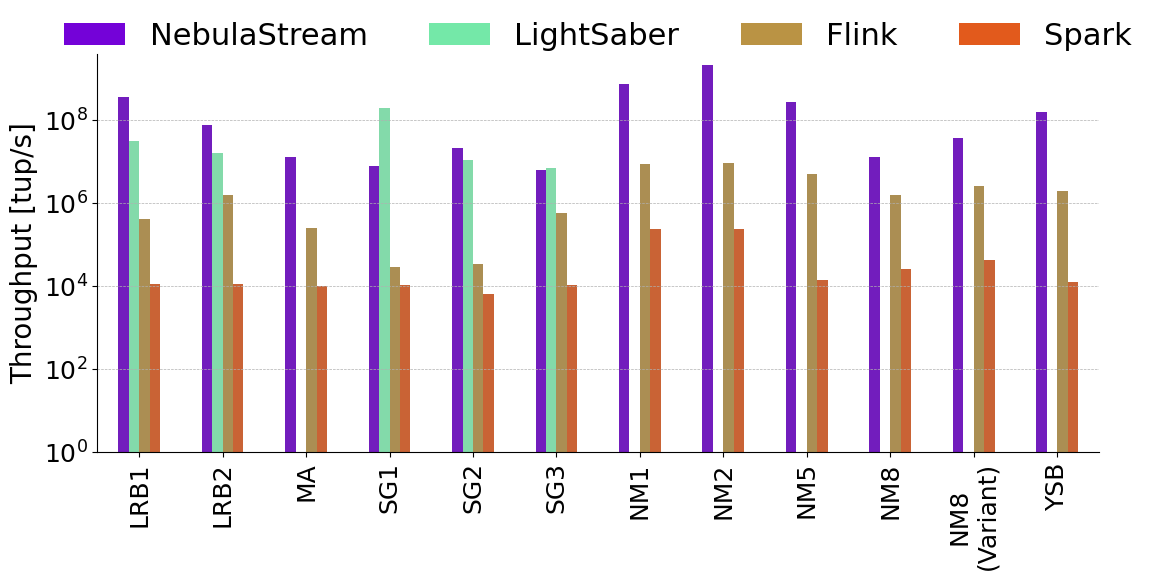

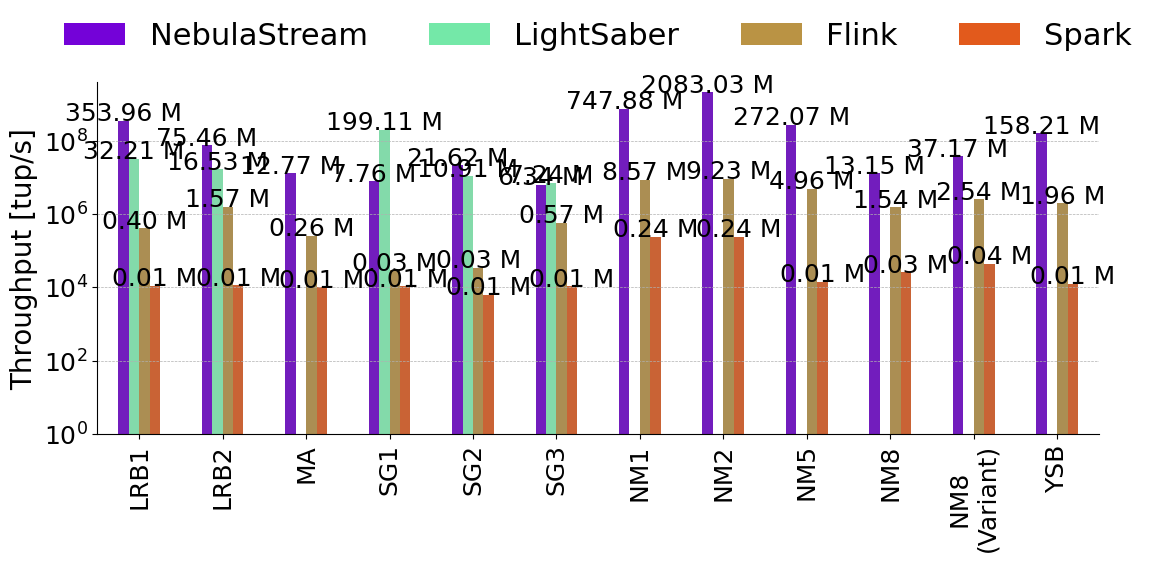

In [2]:
# Filter data for numberOfWorkerThreads == 24
noThreads = 24
cacheType = "SECOND_CHANCE"
df_filtered = df_concatenated[df_concatenated['parallelism'] == noThreads]
df_filtered = df_filtered[(df_filtered['system'] == 'Spark') | (df_filtered['system'] == 'LightSaber') | (df_filtered['system'] == 'Flink') | ((df_filtered['system'] == 'NebulaStream') & (df_filtered['sliceCacheType'] == cacheType))]
#df_filtered = df_filtered[(df_filtered['system'] == 'Spark') | ((df_filtered['system'] == 'NebulaStream') & (df_filtered['sliceCacheType'] == cacheType))]
#x_order = ["CM1", "CM2", "LRB1", "LRB2", "MA", "SG1", "SG2", "SG3", "NM1", "NM2", "NM5", "NM8\n(Variant)", "NM8", "YSB1k", "YSB10k"]
x_order = ["LRB1", "LRB2", "MA", "SG1", "SG2", "SG3", "NM1", "NM2", "NM5", "NM8", "NM8\n(Variant)", "YSB"]

#df_filtered = df_concatenated
# Create and save the bar plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_filtered, x='query_name', y='tuplesPerSecond', hue='system', palette=custom_palette, hue_order=hue_order, order=x_order, dodge=0.2, width=0.5, legend=False, errorbar=None)
#plt.title(f'Tuples per Second for numberOfWorkerThreads == {noThreads}')
plt.xticks(rotation=90, fontsize=18)
plt.xlabel("")
plt.ylabel("Throughput [tup/s]", fontsize=20)
plt.yticks(fontsize=18)
plt.yscale('log')
plt.ylim(1)
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

patches_groups, baseline_group = split_patches(ax.patches, len(hue_order), len(x_order))
messages = create_speedup_message(patches_groups, baseline_group)
print(messages)

# Annotate the bars
#for pid, p in enumerate(baseline_group):
#    ax.annotate(messages[pid],
#                (p.get_x(), p.get_height() * 1.5),
#                ha='center', va='center', xytext=(0, 5), fontsize = 18,
#                textcoords='offset points', rotation=0)

ax.legend(title='', handles=legend_handles, fontsize=22, title_fontsize=22, labels=hue_order,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    frameon=False)        
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'system_comparison.pdf'))
plt.show()
plt.close()


#df_filtered = df_concatenated
# Create and save the bar plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_filtered, x='query_name', y='tuplesPerSecond', hue='system', palette=custom_palette, hue_order=hue_order, order=x_order, dodge=0.2, width=0.5, legend=False, errorbar=None)
#plt.title(f'Tuples per Second for numberOfWorkerThreads == {noThreads}')
plt.xticks(rotation=90, fontsize=18)
plt.xlabel("")
plt.ylabel("Throughput [tup/s]", fontsize=20)
plt.yticks(fontsize=18)
plt.yscale('log')
plt.ylim(1)
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate the bars with values in millions per second
for p in ax.patches:
        ax.annotate(f'{p.get_height() / 1e6:.2f} M',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), fontsize = 18,
                textcoords='offset points')

ax.legend(title='', handles=legend_handles, fontsize=22, title_fontsize=22, labels=hue_order,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=4,
    frameon=False)        
plt.tight_layout()
plt.show()
plt.close()

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


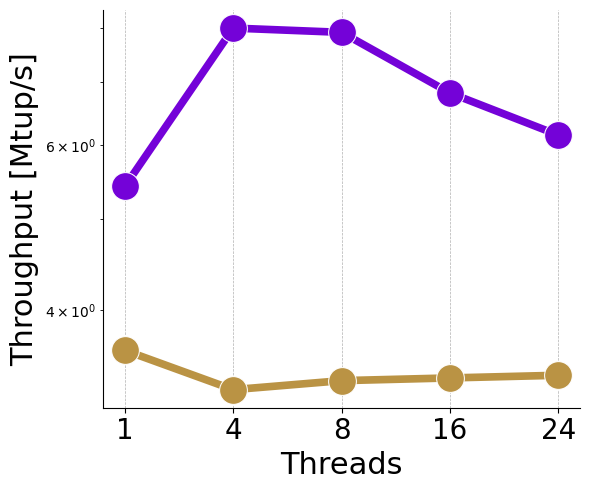

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


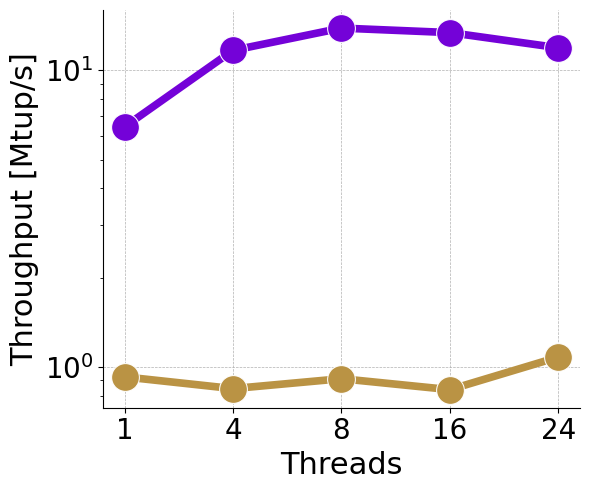

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


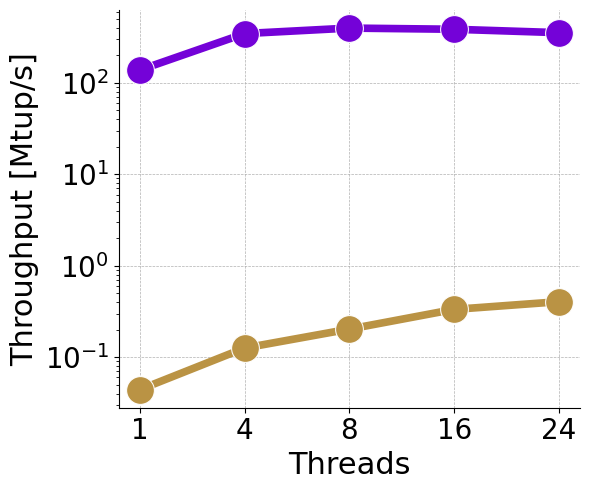

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


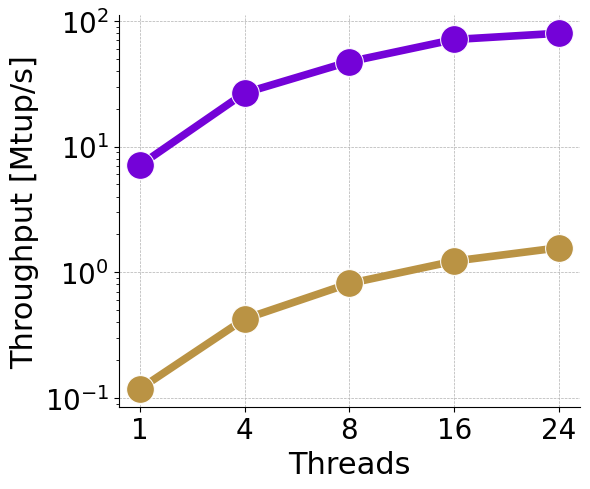

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


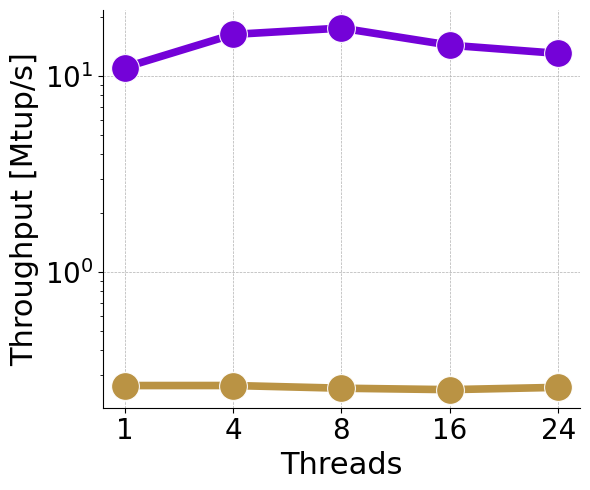

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


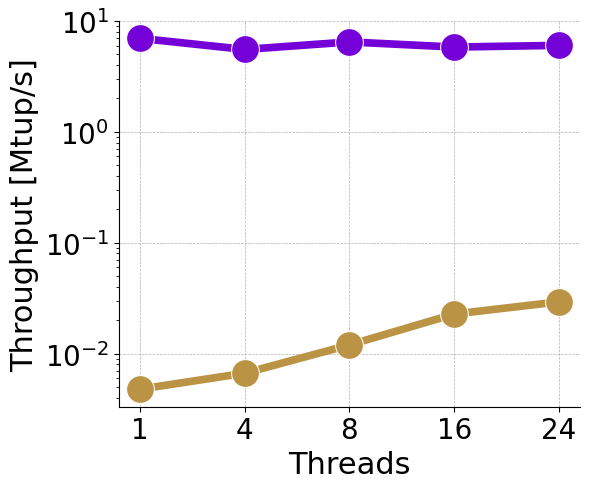

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


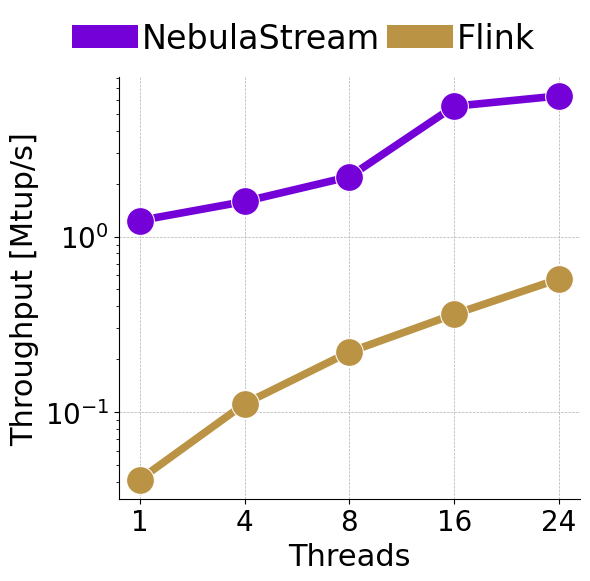

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


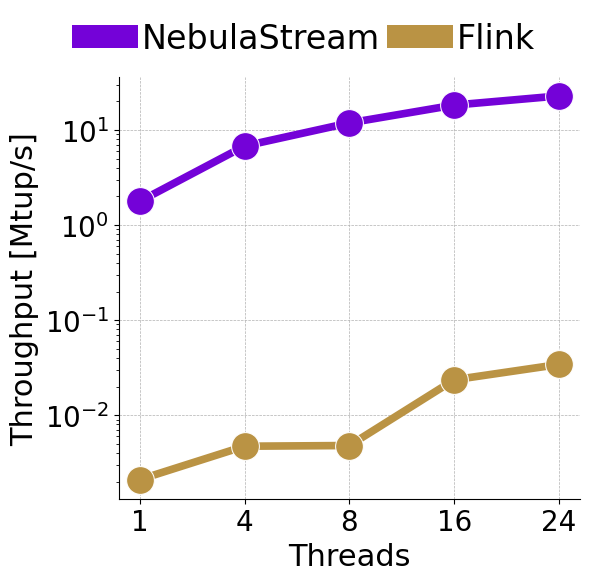

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


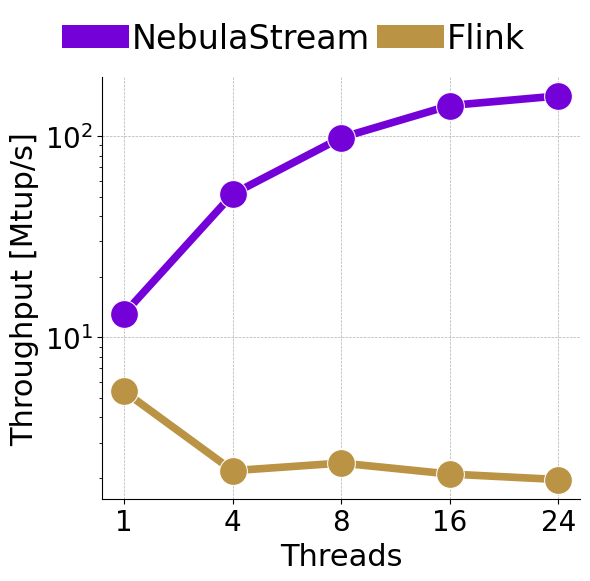

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


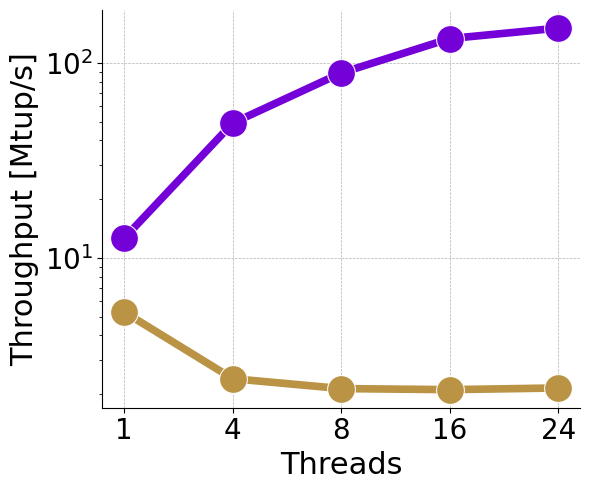

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


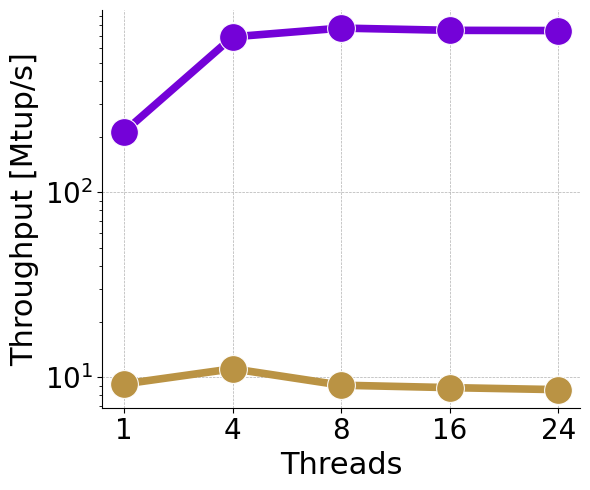

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


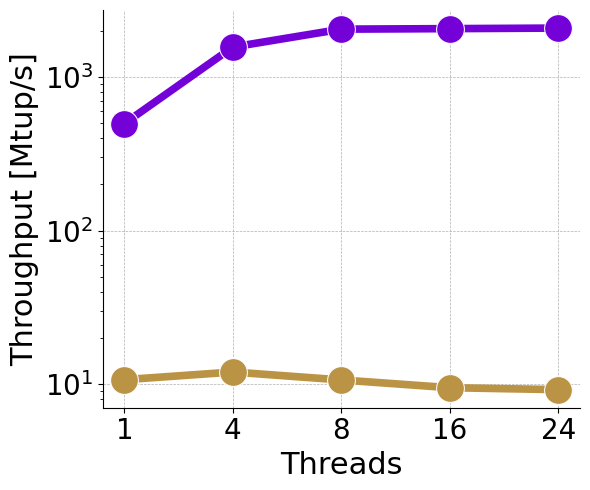

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


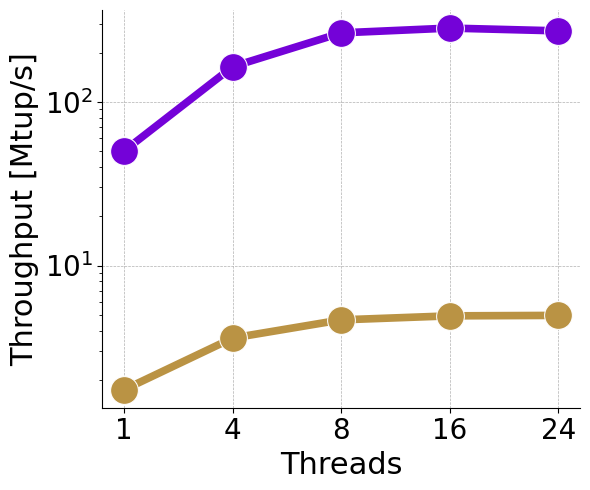

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


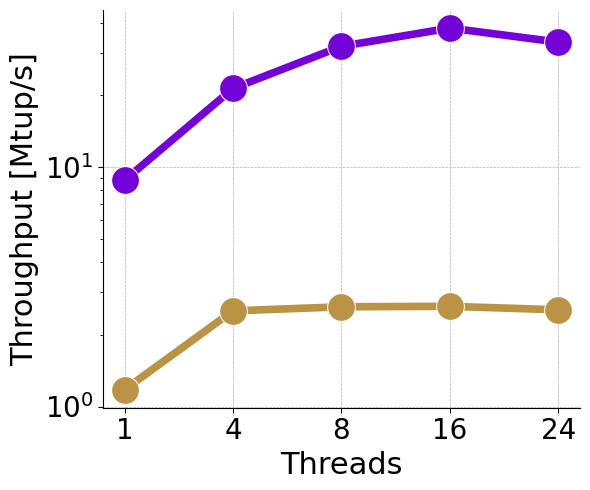

/tmp/ipykernel_15238/982849284.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
/tmp/ipykernel_15238/982849284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['parallelism_str'] = df_query['parallelism'].astype(str)


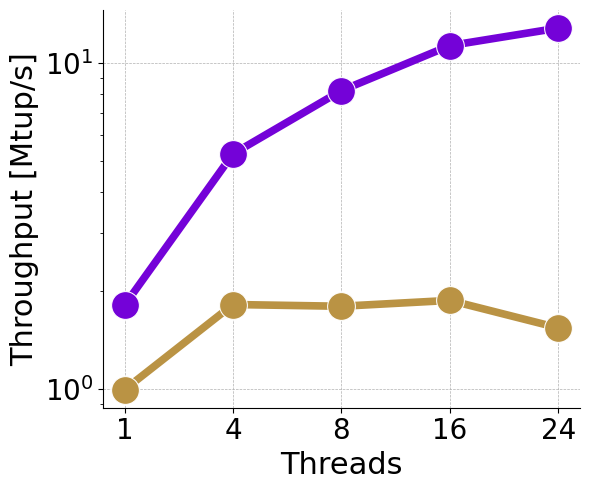

In [3]:
# Create and save line plots for each query_name\n",
queries = df_concatenated['query_name'].unique()
cacheType = "SECOND_CHANCE"
df_filtered = df_concatenated
#df_filtered = df_filtered[(df_filtered['system'] == 'Spark') | (df_filtered['system'] == 'LightSaber') | (df_filtered['system'] == 'Flink') | ((df_filtered['system'] == 'NebulaStream') & (df_filtered['sliceCacheType'] == cacheType))]
#df_filtered = df_filtered[(df_filtered['system'] == 'LightSaber') | (df_filtered['system'] == 'Flink') | ((df_filtered['system'] == 'NebulaStream') & (df_filtered['sliceCacheType'] == cacheType))]
df_filtered = df_filtered[(df_filtered['system'] == 'Flink') | ((df_filtered['system'] == 'NebulaStream') & (df_filtered['sliceCacheType'] == cacheType))]
df_filtered = df_filtered[df_filtered['parallelism'].isin([1, 4, 8, 16, 24])]

for query in queries:
    df_query = df_filtered[df_filtered['query_name'] == query]
    df_query['millionTuplesPerSecond'] = df_query['tuplesPerSecond_e2e'] / 1e6
    df_query['parallelism_str'] = df_query['parallelism'].astype(str)

    # Filter out systems with no data or only zero values
    systems_with_data = df_query[df_query['millionTuplesPerSecond'] > 0]['system'].unique()

    # Only plot if there are systems with data
    if len(systems_with_data) > 0:
        # Update hue_order and legend_handles dynamically
        tmp_hue_order = [s for s in hue_order if s in systems_with_data]
        tmp_legend_handles = [h for h, s in zip(legend_handles, hue_order) if s in systems_with_data]
        tmp_custom_palette = [patch.get_facecolor() for patch in tmp_legend_handles]

        if query in ["YSB", "SG2", "SG3"]:
            plt.figure(figsize=(6, 6))
        else:
            plt.figure(figsize=(6, 5))
        
        ax = sns.lineplot(
            data=df_query[df_query['system'].isin(systems_with_data)],
            x='parallelism_str',
            y='millionTuplesPerSecond',
            hue='system',
            marker='o',
            markersize=20,
            linewidth=5.5,
            palette=tmp_custom_palette,
            hue_order=tmp_hue_order
        )
        if query in ["YSB", "SG2", "SG3"]:
            plt.legend(
                title='',
                handles=tmp_legend_handles,
                fontsize=24,
                title_fontsize=14,
                labels=tmp_hue_order,
                loc='upper center',
                bbox_to_anchor=(0.4, 1.2),
                handletextpad=0.1,
                columnspacing=0.2,
                ncol=2,
                frameon=False
            )
        else:
            plt.legend().set_visible(False)
            

        plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #plt.title(f'Tuples per Second for {query}')
        plt.xticks(rotation=0, fontsize=20)
        plt.xlabel("Threads", fontsize=22)
        plt.ylabel("Throughput [Mtup/s]", fontsize=22)
        plt.yscale('log')
        plt.yticks(fontsize=20)
        plt.tight_layout()

        query_name = str(query).replace("NM8\n(Variant)", "NM8_Variant")
        filename = f"{query_name}_parallelism_tuplesPerSecond.pdf"
        plt.savefig(os.path.join(output_dir, filename))
        plt.show()
        plt.close()
